<a href="https://colab.research.google.com/github/kjahan/stable_diffusion_demo/blob/master/notebooks/prompt_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Prompt engineering

#### Stable Diffusion v1.5 vs Midjourney v4 Diffusion


https://huggingface.co/prompthero/midjourney-v4-diffusion

https://github.com/amrrs/midjourney4-stable-diffusion/blob/main/MidJourney_Style_Images_from_Fine_tuned_Stable_Diffusion.ipynb

https://www.youtube.com/watch?v=nYi1dE3qK6U



In [1]:
!pip install transformers diffusers accelerate -q

     |████████████████████████████████| 5.5 MB 5.8 MB/s 
     |████████████████████████████████| 304 kB 59.7 MB/s 
     |████████████████████████████████| 175 kB 66.5 MB/s 
     |████████████████████████████████| 182 kB 71.9 MB/s 
     |████████████████████████████████| 7.6 MB 55.7 MB/s 


## Imports

In [3]:
from diffusers import StableDiffusionPipeline
import torch

import time

In [4]:
model_path = 'prompthero/midjourney-v4-diffusion'
pipe = StableDiffusionPipeline.from_pretrained(model_path , torch_dtype=torch.float16)

Downloading:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Downloading:   0%|          | 0.00/342 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/4.84k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

Downloading:   0%|          | 0.00/743 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/547 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/335M [00:00<?, ?B/s]

ftfy or spacy is not installed using BERT BasicTokenizer instead of ftfy.


In [5]:
!nvidia-smi

Sat Nov 19 19:09:11 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   49C    P8    12W /  70W |      3MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [6]:
if torch.cuda.is_available():
  pipe = pipe.to("cuda")

device = "GPU 🔥" if torch.cuda.is_available() else "CPU 🥶"

## Genrative func

In [7]:
def generate_image(pos_prompt, neg_prompt=""):
  prompt = "mdjrny-v4 style " + pos_prompt

  print(prompt)
  if neg_prompt:
    result = pipe(
          prompt=pos_prompt,
          negative_prompt=neg_prompt,
          width = 512,
          height = 512)
  else:
    result = pipe(
          prompt=pos_prompt,
          width = 512,
          height = 512)

  image = result.images[0]  
      
  image.save("sd_img_{}.png".format(int(time.time())))

  return image

## Try new prompt 1

"ufo,vintage photographs,ultra realistic,greyscale,onlookers,8k —ar 4:5"

https://ai-image-posting-service.com/artworks/1666890422771x807136388883415000

mdjrny-v4 style beautiful, painting, painter, plant, flower, sky


  0%|          | 0/51 [00:00<?, ?it/s]

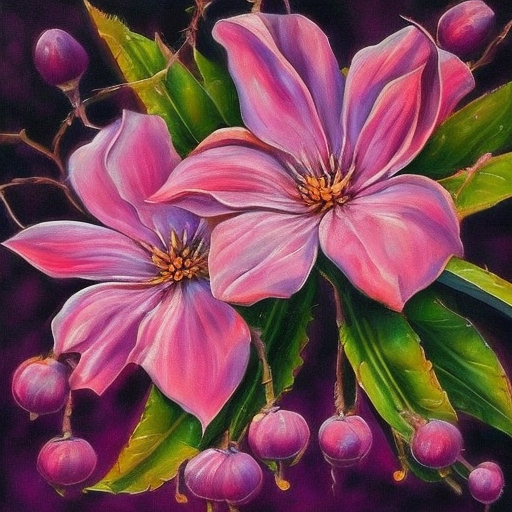

In [14]:
prompt = """beautiful, painting, painter, plant, flower, sky"""

generate_image(prompt)

## Prompt 2

https://ai-image-posting-service.com/artworks/1666950061406x370914422201516000

`positive
((masterpiece)) , (((best quality))),((ultra-detailed)), ((illustration)), (night),  Autumn leaves, japan, ((waterfall)), moon, waterfall basin,  starry sky, waterfall lake, midnight, landscape`

`negative
monochrome, cropped, worst quality, low quality, alphabet, (((((watermark))))), ((Impressionism)), daytime, sun, cloudy, Shiraito Falls, Free stock images, woodblock prints, black, balls, curve, fog`

mdjrny-v4 style ((masterpiece)) , (((best quality))),((ultra-detailed)), ((illustration)), (night),  Autumn leaves, japan, ((waterfall)), moon, waterfall basin,  starry sky, waterfall lake, midnight, landscape


  0%|          | 0/51 [00:00<?, ?it/s]

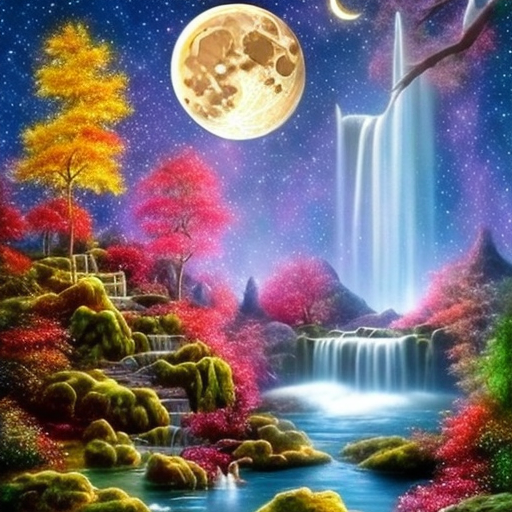

In [16]:
pos_prompt = """((masterpiece)) , (((best quality))),((ultra-detailed)), ((illustration)), (night),  Autumn leaves, japan, ((waterfall)), moon, waterfall basin,  starry sky, waterfall lake, midnight, landscape"""
neg_prompt = """monochrome, cropped, worst quality, low quality, alphabet, (((((watermark))))), ((Impressionism)), daytime, sun, cloudy, Shiraito Falls, Free stock images, woodblock prints, black, balls, curve, fog"""

generate_image(pos_prompt, neg_prompt)

mdjrny-v4 style masterpiece,best quality, an extremely delicate and beautiful, , Clear sky,  depth of field, beautiful detailed sky, blue sky, beautiful detailed cloud, beautiful detailed water, , {extremely detailed CG unity 8k wallpaper},   dynamic angle, floating, shiny,nature,sunlight ,1girl,from behaind,summer


  0%|          | 0/51 [00:00<?, ?it/s]

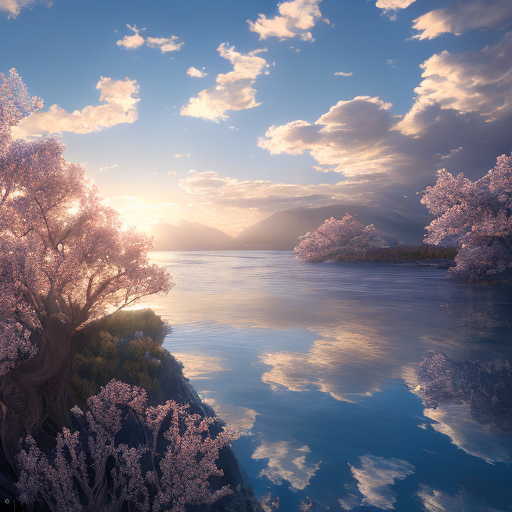

In [17]:
pos_prompt = "masterpiece,best quality, an extremely delicate and beautiful, , Clear sky,  depth of field, beautiful detailed sky, blue sky, beautiful detailed cloud, beautiful detailed water, , {extremely detailed CG unity 8k wallpaper},   dynamic angle, floating, shiny,nature,sunlight ,1girl,from behaind,summer"


neg_prompt = "lowres, bad anatomy, bad hands, text, error, missing fingers, extra digit, fewer digits, cropped, worst quality, low quality"

generate_image(pos_prompt, neg_prompt)


## Prompt 3

https://lexica.art/?prompt=0f7df637-cb98-4a84-8306-2b66e958fec8

mdjrny-v4 style detailed portrait neon operator lady, blonde long messy hair, cyberpunk futuristic, neon, reflective puffy coat, decorated with traditional japanese by ismail inceoglu dragan bibin hans thoma greg rutkowski alexandros pyromallis nekro rene margitte, illustrated, perfect face, fine details, realistic shaded, fine - face, pretty face 


  0%|          | 0/51 [00:00<?, ?it/s]

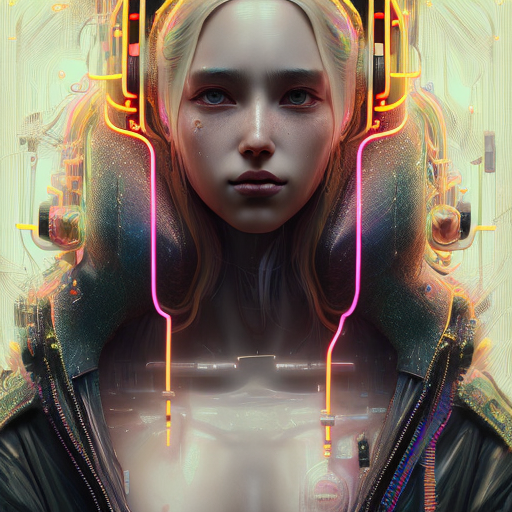

In [20]:
pos_prompt = """detailed portrait neon operator lady, blonde long messy hair, cyberpunk futuristic, neon, reflective puffy coat, decorated with traditional japanese by ismail inceoglu dragan bibin hans thoma greg rutkowski alexandros pyromallis nekro rene margitte, illustrated, perfect face, fine details, realistic shaded, fine - face, pretty face """

generate_image(pos_prompt)


## Prompt 4



mdjrny-v4 style realistic detailed face portrait of a beautiful futuristic ukiyo geisha with pale skin, blue lips in alien cyberpunk armor by, ayami kojima, amano, greg hildebrandt, alphonse mucha, moebius, and mark brooks, female, feminine, art nouveau, cyberpunk, neo - gothic, gothic, character concept design 


  0%|          | 0/51 [00:00<?, ?it/s]

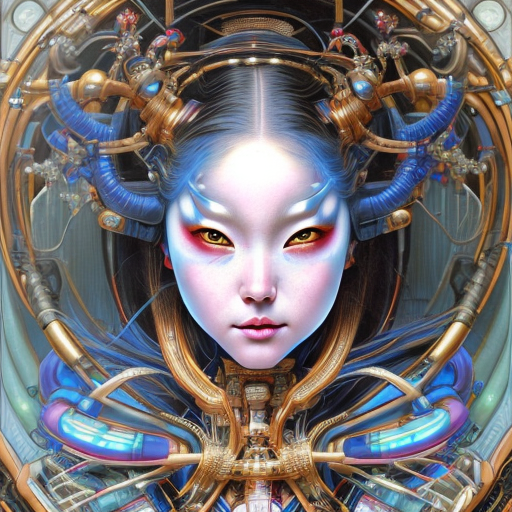

In [21]:
pos_prompt = """realistic detailed face portrait of a beautiful futuristic ukiyo geisha with pale skin, blue lips in alien cyberpunk armor by, ayami kojima, amano, greg hildebrandt, alphonse mucha, moebius, and mark brooks, female, feminine, art nouveau, cyberpunk, neo - gothic, gothic, character concept design """

generate_image(pos_prompt)

## Prompt 5

https://sugar.cf/2022/11/18/844/

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['extension, detail details, 1 girl, { { { album cover } } }, viewer ’ s eyes, ( ( floating hair ) ), official art, { { { beautifully detailed eyes } } }, { { { beautifully detailed face } } }, { { { beautifully detailed hair } } }, { { { beautifully detailed dressing } } }, a large number of particles with limited colors, { { { stylish clothes, disheveled hair, wind } } }, highly detailed fingers, beautiful detailed faces, wavy curly, zentangle <|endoftext|>']


mdjrny-v4 style White skin, {{{oil painting}}}, {{{high definition light, sharp sketch}}}, {{{cyberpunk}}}, {{{dynamic pose}}}, strong twisted body, { {{cute anime face loli}}}, {{{dynamic angle}}}, poptoon, hair inner color, hairline extension, detail details, 1girl, {{{album cover}}}, viewer’s eyes, (( floating hair)), official art, {{{beautifully detailed eyes}}}, {{{beautifully detailed face}}}, {{{beautifully detailed hair}}}, {{ {beautifully detailed dressing} } }, a large number of particles with limited colors, {{{stylish clothes, disheveled hair, wind}}}, highly detailed fingers, beautiful detailed faces, wavy curly ,zentangle


  0%|          | 0/51 [00:00<?, ?it/s]

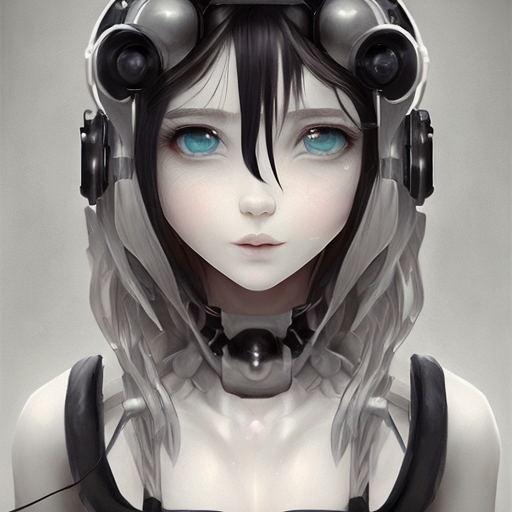

In [26]:
pos_prompt = """White skin, {{{oil painting}}}, {{{high definition light, sharp sketch}}}, {{{cyberpunk}}}, {{{dynamic pose}}}, strong twisted body, { {{cute anime face loli}}}, {{{dynamic angle}}}, poptoon, hair inner color, hairline extension, detail details, 1girl, {{{album cover}}}, viewer’s eyes, (( floating hair)), official art, {{{beautifully detailed eyes}}}, {{{beautifully detailed face}}}, {{{beautifully detailed hair}}}, {{ {beautifully detailed dressing} } }, a large number of particles with limited colors, {{{stylish clothes, disheveled hair, wind}}}, highly detailed fingers, beautiful detailed faces, wavy curly ,zentangle"""

generate_image(pos_prompt)

## Prompt 6

https://sugar.cf/2022/10/04/666/

mdjrny-v4 style Cyber ​​security, the background is a big key of cyberpunk floating, Anubis god, light blue translucent body running light patterns reminiscent of the cyber world such as electrical signals and computer circuits, upper body, realistic, complex, background is cyber big punk key floating, HQ, 8k –ar 2:3 –upbeta –v 3


  0%|          | 0/51 [00:00<?, ?it/s]

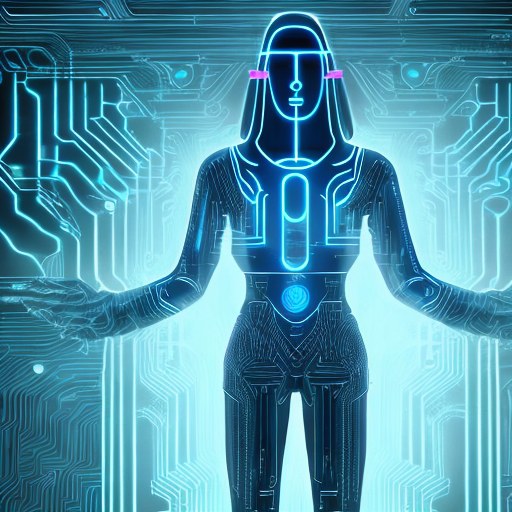

In [27]:
pos_prompt = """Cyber ​​security, the background is a big key of cyberpunk floating, Anubis god, light blue translucent body running light patterns reminiscent of the cyber world such as electrical signals and computer circuits, upper body, realistic, complex, background is cyber big punk key floating, HQ, 8k –ar 2:3 –upbeta –v 3"""

generate_image(pos_prompt)